In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("titanic")

In [82]:
# phase 1: Load and inspect
print(df.shape)

(891, 15)


In [83]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [85]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [86]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [87]:
# phase 2: DATA CLEANING
df = df.drop_duplicates()


In [89]:
df["sex"] = df["sex"].str.strip()
df["class"] = df["class"].astype(str).str.strip()
df["embark_town"] = df["embark_town"].str.strip()

In [90]:
df["age"] = df["age"].fillna(df["age"].median())

In [91]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [92]:
df["deck"] = df["deck"].astype(str).replace("nan", "unknown")

In [93]:
df["age"] = df["age"].astype(int)
df["fare"] = df["fare"].astype(float)

In [94]:
df["family_size"] = df["sibsp"] + df["parch"] + 1


In [95]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

In [96]:
df["fare_per_person"] = df["fare"] / df["family_size"]


(array([ 29.,  20.,  18.,  15.,  76.,  75.,  84., 190.,  63.,  53.,  39.,
         34.,  31.,  18.,  13.,  13.,   6.,   5.,   1.,   1.]),
 array([ 0.,  4.,  8., 12., 16., 20., 24., 28., 32., 36., 40., 44., 48.,
        52., 56., 60., 64., 68., 72., 76., 80.]),
 <BarContainer object of 20 artists>)

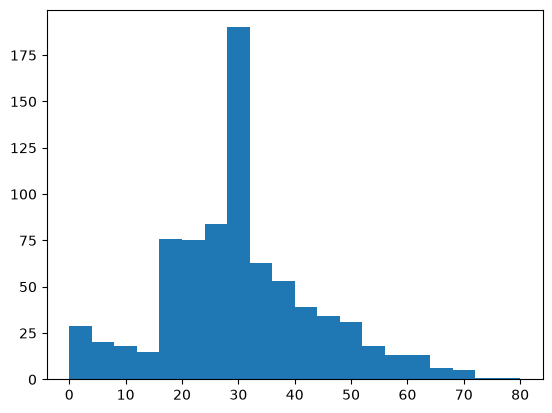

In [97]:
#phase 3: Explore (Charts)
plt.hist(df["age"], bins=20)

<Axes: xlabel='sex'>

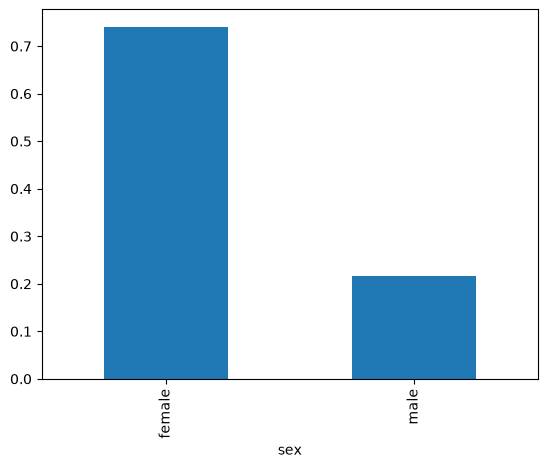

In [98]:
df.groupby("sex")["survived"].mean().plot(kind="bar")

<Axes: >

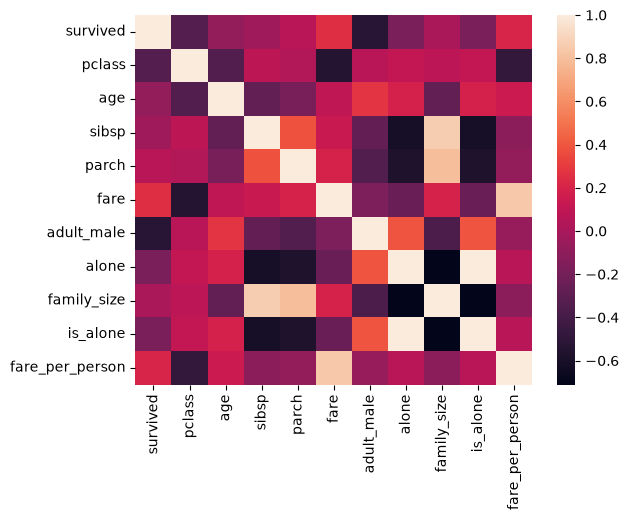

In [99]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='class'>

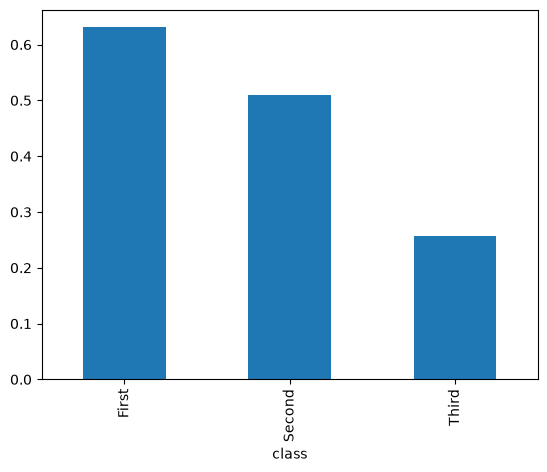

In [100]:
df.groupby("class")["survived"].mean().plot(kind="bar")

In [101]:

df.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   survived         784 non-null    int64  
 1   pclass           784 non-null    int64  
 2   sex              784 non-null    str    
 3   age              784 non-null    int64  
 4   sibsp            784 non-null    int64  
 5   parch            784 non-null    int64  
 6   fare             784 non-null    float64
 7   embarked         782 non-null    str    
 8   class            784 non-null    str    
 9   who              784 non-null    str    
 10  adult_male       784 non-null    bool   
 11  deck             202 non-null    str    
 12  embark_town      784 non-null    str    
 13  alive            784 non-null    str    
 14  alone            784 non-null    bool   
 15  family_size      784 non-null    int64  
 16  is_alone         784 non-null    int64  
 17  fare_per_person  784 non-null   

In [102]:
df.drop(columns=['embark_town','class','alive','deck','alone','who'], inplace= True, errors = 'ignore')

In [1]:
df = pd.get_dummies(df, columns=['sex','embarked','adult_male'], dtype=int)

NameError: name 'pd' is not defined

In [76]:
df.head()


,survived,pclass,age,sibsp,parch,fare,class,who,deck,embark_town,alive,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,adult_male_False,adult_male_True
0,0,3,22.0,1,0,7.2500,third,man,NaN,southampton,no,False,0,1,0,0,1,0,1
1,1,1,38.0,1,0,71.2833,first,woman,C,cherbourg,yes,False,1,0,1,0,0,1,0
2,1,3,26.0,0,0,7.9250,third,woman,NaN,southampton,yes,True,1,0,0,0,1,1,0
3,1,1,35.0,1,0,53.1000,first,woman,C,southampton,yes,False,1,0,0,0,1,1,0
4,0,3,35.0,0,0,8.0500,third,man,NaN,southampton,no,True,0,1,0,0,1,0,1


In [2]:
df.info()

NameError: name 'df' is not defined